# LightGBM for Sales Drop Detection

## Overview and Model Selection Rationale

This notebook is part of a comparative study of three approaches (TCN, LightGBM, and Isolation Forest) for detecting anomalous hourly sales drops. All models use the **exact same** dataset, preprocessing pipeline, and product selection (top-500 products by August sales volume + 13 products with labeled anomalies). This ensures a fair and reproducible comparison.

**Why LightGBM was chosen as the primary model:**
- Best regression metrics on the validation set (MAE/RMSE improvement of approximately 50% over the naïve baseline).
- Excellent performance on highly intermittent demand (96.83% zero sales according to EDA).
- Superior scalability — unlike TCN, it can be trained on the entire product catalog (10,000+ items).
- High interpretability (feature importance) and fast inference speed, which are critical for production deployment.
- Uses Huber loss (`alpha=0.9`), deliberately aligned with TCN's `HuberLoss(delta=1.0)` to eliminate loss function differences from the comparison.

**Model parameters are fully justified by EDA:**
- Lag and rolling window features (6/24/168 hours) correspond to daily and weekly seasonality identified in exploratory analysis.
- Sample weight of 3.0 for non-zero sales directly addresses the high zero-inflation rate (96.83%) and strong positive skew (skewness ≈ 13.75).
- Product and category codes as categorical features leverage LightGBM's native support for categorical variables.

**Anomaly detection approach:**
The model is trained **only once** on January–July data. In August, residuals between predicted and actual sales are computed. Hours where the model expected sales but actual sales were zero (or near zero) produce large positive residuals. A global z-score threshold applied to these residuals identifies anomalous hours. Three threshold variants are evaluated on the same predictions: `z > 2.0`, `z > 3.0`, and `z > 4.5`.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import gc

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


In [14]:
DATA_PATH       = r'data_v1.csv'
AUG_AN_PATH     = r'df_aug_final.csv'
AUG_ZERO_PATH   = r'df_aug_final_check_rows.csv'
OUTPUT_PATH   = r'detected_anomalies_august_lgbm_z4.csv'
#OUTPUT_PATH   = r'detected_anomalies_august_lgbm_z2.csv'

## Data Loading and Filtering

Raw sales data covers January–August 2025. August is replaced with the anomaly-injected version (`df_aug_final.csv`), where sales at 65 specific (product, date, hour) coordinates have been set to zero. Training uses only the original pre-August data; the injected zeros are present only in the test period.

Cold-start products — those with no sales history prior to August — are excluded, as no reliable baseline can be established for them. The model scope is further restricted to the top-500 products by August sales volume plus the 13 products containing labeled anomalies, ensuring evaluation coverage.

In [3]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
print("Initial size:", df.shape)

df_aug_final = pd.read_csv(AUG_AN_PATH)
df_aug_final['date'] = pd.to_datetime(df_aug_final['date'])
df = df[df['date'] < '2025-08-01'].copy()
df = pd.concat([df, df_aug_final], ignore_index=True)
df = df.sort_values(['product', 'date']).reset_index(drop=True)
del df_aug_final
gc.collect()

print(f"After replacing August: {df.shape}, period: {df['date'].min()} — {df['date'].max()}")

df = df[df['date'] <= '2025-08-31'].copy()
first_pos = df[df['sales'] > 0].groupby('product')['date'].min()
aug_start = pd.Timestamp('2025-08-01')
cold = first_pos[first_pos >= aug_start].index.tolist()
df = df[~df['product'].isin(cold)].copy()
print(f"After removing cold-start products: {df.shape}")



aug_df = df[df['date'] >= aug_start].copy()
prod_sales = aug_df.groupby('product')['sales'].sum().reset_index()
top_500 = prod_sales.nlargest(500, 'sales')['product'].tolist()

df_aug_zero = pd.read_csv(AUG_ZERO_PATH)
anomaly_products = df_aug_zero['product'].unique().tolist()

selected_products = list(set(top_500 + anomaly_products))
print(f"Top-500: {len(top_500)} | Anomaly products: {len(anomaly_products)} | Total: {len(selected_products)}")

df = df[df['product'].isin(selected_products)].copy()
print(f"Final dataset: {df.shape}")

del first_pos, cold, prod_sales, aug_df, top_500, anomaly_products, selected_products
gc.collect()

Initial size: (64081080, 6)
After replacing August: (43218240, 7), period: 2025-01-15 00:00:00 — 2025-08-31 23:00:00
After removing cold-start products: (43058022, 7)
Top-500: 500 | Anomaly products: 13 | Total: 500
Final dataset: (2736500, 7)


0

## Feature Engineering

Features are organised into three groups:

**Temporal indicators** — hour of day, day of week, weekend flag, week number, month. Cyclical features (hour and day of week) are encoded as sine/cosine pairs to preserve their circular structure.

**Lag and rolling features** — sales lagged at 1 h, 24 h, and 168 h capture short-term momentum, daily periodicity, and weekly seasonality respectively. Rolling mean and standard deviation over the same windows summarise recent demand level and volatility. Windows are chosen based on the dominant seasonality patterns identified in EDA.

**Stock and identity features** — 1-hour lagged stock level confirms product availability in the preceding hour. Product and category codes are included as categorical features, enabling LightGBM to learn SKU-specific demand patterns natively.

In [4]:
df = df.sort_values(['product', 'date']).reset_index(drop=True)

df['hour']       = df['date'].dt.hour
df['dayofweek']  = df['date'].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['week']       = df['date'].dt.isocalendar().week.astype(int)
df['month']      = df['date'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['dayofweek'] / 7)

df['stocks_lag_1h'] = df.groupby('product')['stocks'].shift(1).fillna(0)

df['sales_lag_1h']   = df.groupby('product')['sales'].shift(1)
df['sales_lag_24h']  = df.groupby('product')['sales'].shift(24)
df['sales_lag_168h'] = df.groupby('product')['sales'].shift(168)

for window in [6, 24, 168]:
    min_p = max(1, window // 2)
    df[f'rolling_mean_{window}h'] = df.groupby('product')['sales'].transform(
        lambda x: x.rolling(window, min_periods=min_p).mean()
    )
    df[f'rolling_std_{window}h'] = df.groupby('product')['sales'].transform(
        lambda x: x.rolling(window, min_periods=min_p).std()
    )

df['product_code']  = df['product'].astype('category').cat.codes
df['category_code'] = df['category'].astype('category').cat.codes

numeric_cols = df.select_dtypes(include=['float64', 'float32', 'int32', 'int64']).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Shape after feature engineering: {df.shape} ({df.shape[1]} columns)")
gc.collect()

Shape after feature engineering: (2736500, 27) (27 columns)


0

## Train / Validation / Test Split

- **Train**: January 1 – July 24 (~4,200 hours per product). No injected anomalies in this period.
- **Validation**: July 25–31 (one full weekly cycle). Used exclusively for early stopping; the model never sees August during training.
- **Test**: August 2025 (anomaly-injected). July 29–31 is included in the test dataframe to provide valid lag features for the first days of August; only August rows are used for anomaly detection.

Note: lag features computed on the training set do not leak August information — `shift()` is applied on the full sorted dataframe before the split, but all August values appear only after the split boundary.

In [5]:
df_train = df[df['date'] <= '2025-07-24'].copy()
df_val   = df[(df['date'] >= '2025-07-25') & (df['date'] <= '2025-07-31')].copy()
df_test  = df[df['date'] >= '2025-07-29'].copy()  # includes late July for lag context

print(f"Train: {len(df_train):,} rows | {df_train['date'].min().date()} — {df_train['date'].max().date()}")
print(f"Val:   {len(df_val):,} rows   | {df_val['date'].min().date()} — {df_val['date'].max().date()}")
print(f"Test:  {len(df_test):,} rows  | {df_test['date'].min().date()} — {df_test['date'].max().date()}")

Train: 2,292,500 rows | 2025-01-15 — 2025-07-24
Val:   72,000 rows   | 2025-07-25 — 2025-07-30
Test:  384,500 rows  | 2025-07-29 — 2025-08-31


## Model Training

**Loss function: `objective='huber'`, `alpha=0.9`** — Huber loss is chosen over MSE because the sales distribution is highly right-skewed with frequent zero values. Squared loss would disproportionately penalise rare large spikes and distort forecasts for typical hours. `alpha=0.9` places the quadratic-to-linear transition near the 90th percentile of residuals, keeping the model sensitive to underforecasting while ignoring extreme upper-tail events. This is intentionally aligned with TCN's `HuberLoss(delta=1.0)` for a fair comparison.

**Sample weights** — non-zero sales observations receive weight 3.0 vs. 1.0 for zero rows. With ~96.83% zero sales, uniform weighting causes the model to learn a near-zero constant. The 3:1 ratio rebalances the training signal toward hours with actual transactions.

**Regularisation** — `min_child_samples=150` prevents product-specific micro-splits on sparse SKUs. `subsample=0.75` and `colsample_bytree=0.65` add stochastic regularisation. L1/L2 penalties (`reg_alpha=0.3`, `reg_lambda=0.8`) encourage sparse feature usage. Early stopping on the validation set determines the actual number of trees used.

In [6]:
feature_cols = [col for col in df_train.columns if col not in
                ['product', 'date', 'category', 'sales']]

X_train = df_train[feature_cols]
y_train = df_train['sales']
X_val   = df_val[feature_cols]
y_val   = df_val['sales']

sample_weight     = np.where(y_train > 0, 3.0, 1.0)
sample_weight_val = np.where(y_val   > 0, 3.0, 1.0)

model_lgbm = lgb.LGBMRegressor(
    objective='huber',
    alpha=0.9,
    metric='mae',
    learning_rate=0.05,
    n_estimators=1500,
    num_leaves=48,
    max_depth=7,
    min_child_samples=150,
    subsample=0.75,
    colsample_bytree=0.65,
    reg_alpha=0.3,
    reg_lambda=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_lgbm.fit(
    X_train, y_train,
    sample_weight=sample_weight,
    eval_set=[(X_val, y_val)],
    eval_sample_weight=[sample_weight_val],
    callbacks=[
        lgb.early_stopping(30, verbose=True),
        lgb.log_evaluation(100)
    ]
)

print(f"Best iteration: {model_lgbm.best_iteration_}")

Training until validation scores don't improve for 30 rounds
[100]	valid_0's l1: 0.791144
[200]	valid_0's l1: 0.730012
[300]	valid_0's l1: 0.699017
[400]	valid_0's l1: 0.676022
[500]	valid_0's l1: 0.653638
[600]	valid_0's l1: 0.631913
[700]	valid_0's l1: 0.612576
[800]	valid_0's l1: 0.594392
[900]	valid_0's l1: 0.579718
[1000]	valid_0's l1: 0.560986
[1100]	valid_0's l1: 0.545726
[1200]	valid_0's l1: 0.531568
[1300]	valid_0's l1: 0.516723
[1400]	valid_0's l1: 0.50272
[1500]	valid_0's l1: 0.490671
Did not meet early stopping. Best iteration is:
[1500]	valid_0's l1: 0.490671
Best iteration: 1500


# Validation metrics

In [7]:
val_preds   = np.clip(model_lgbm.predict(X_val), 0, None)
val_targets = y_val.values

model_mae  = mean_absolute_error(val_targets, val_preds)
model_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))

naive_mae  = mean_absolute_error(val_targets[1:], val_targets[:-1])
naive_rmse = np.sqrt(mean_squared_error(val_targets[1:], val_targets[:-1]))

print(f"{'Metric':<12} {'Naive baseline':>15} {'LightGBM':>10}")
print(f"{'MAE':<12} {naive_mae:>15.3f} {model_mae:>10.3f}")
print(f"{'RMSE':<12} {naive_rmse:>15.3f} {model_rmse:>10.3f}")
print(f"\nMAE  improvement: {(1 - model_mae  / naive_mae)  * 100:.1f}%")
print(f"RMSE improvement: {(1 - model_rmse / naive_rmse) * 100:.1f}%")

Metric        Naive baseline   LightGBM
MAE                    0.682      0.332
RMSE                   2.046      1.117

MAE  improvement: 51.3%
RMSE improvement: 45.4%


# Predict on test set (August only)

In [8]:
X_test = df_test[feature_cols]
df_test = df_test.copy()
df_test['predicted_sales'] = np.clip(model_lgbm.predict(X_test), 0, None)

df_aug_pred = df_test[df_test['date'] >= '2025-08-01'].copy()

print(f"August prediction rows: {len(df_aug_pred):,}")
print(f"Products:               {df_aug_pred['product'].nunique()}")

August prediction rows: 360,500
Products:               500


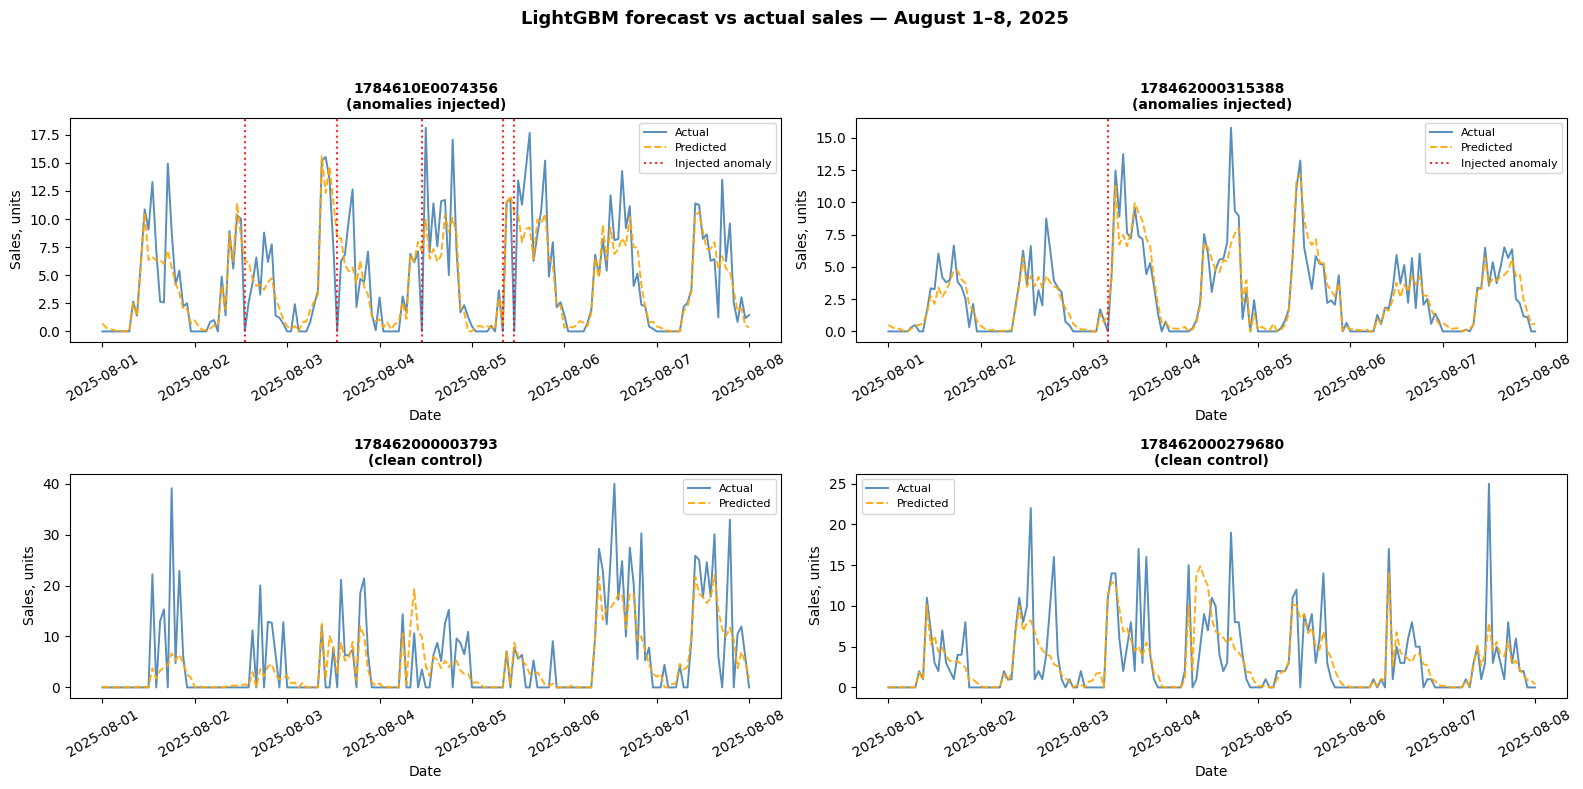

In [9]:
df_aug_an_zero = pd.read_csv(AUG_ZERO_PATH)
df_aug_an_zero['date'] = pd.to_datetime(df_aug_an_zero['date'])
df_aug_an_zero['product'] = df_aug_an_zero['product'].astype(str)

anomaly_products_sample = df_aug_an_zero['product'].unique()[:2].tolist()
known_anom_set = set(df_aug_an_zero['product'].astype(str))
control_products = (
    df_aug_pred[~df_aug_pred['product'].astype(str).isin(known_anom_set)]
    .groupby('product')['sales'].sum()
    .nlargest(2).index.tolist()
)

products_to_plot = anomaly_products_sample + control_products
labels = (
    [f"{p}\n(anomalies injected)" for p in anomaly_products_sample]
    + [f"{p}\n(clean control)"    for p in control_products]
)

zoom_start = pd.Timestamp('2025-08-01')
zoom_end   = pd.Timestamp('2025-08-08')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, prod, label in zip(axes, products_to_plot, labels):
    prod_data = (
        df_aug_pred[
            (df_aug_pred['product'].astype(str) == str(prod)) &
            (df_aug_pred['date'] >= zoom_start) &
            (df_aug_pred['date'] <= zoom_end)
        ].sort_values('date')
    )
    ax.plot(prod_data['date'], prod_data['sales'],
            label='Actual', color='steelblue', linewidth=1.4, alpha=0.9)
    ax.plot(prod_data['date'], prod_data['predicted_sales'],
            label='Predicted', color='orange', linewidth=1.4, linestyle='--', alpha=0.9)

    anom_rows = df_aug_an_zero[
        (df_aug_an_zero['product'].astype(str) == str(prod)) &
        (df_aug_an_zero['date'] >= zoom_start) &
        (df_aug_an_zero['date'] <= zoom_end)
    ]
    for _, row in anom_rows.iterrows():
        ax.axvline(pd.to_datetime(row['date']), color='red',
                   linewidth=1.5, linestyle=':', alpha=0.85, label='Injected anomaly')

    handles, lbls = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, lbls):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales, units')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('LightGBM forecast vs actual sales — August 1–8, 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Anomaly Detection

The anomaly score is the **global z-score of the residual** across all August predictions:

$$z_i = \frac{r_i - \bar{r}}{\sigma_r}, \quad r_i = \hat{y}_i - y_i$$

A large positive residual means the model expected sales but actual sales were low — the pattern consistent with an out-of-stock event. Three mandatory pre-filters are applied before the z-score threshold:
- stock was positive at hour $t$ (product was on shelf),
- stock was positive at hour $t-1$ (product was available in the preceding hour),
- hour falls within operating hours 07:00–22:00.

The threshold is then selected based on the recall/precision trade-off evaluated against the 65 labeled synthetic anomalies.

In [10]:
df_aug_pred['residual'] = df_aug_pred['predicted_sales'] - df_aug_pred['sales']

df_aug_pred['residual_zscore'] = (
    (df_aug_pred['residual'] - df_aug_pred['residual'].mean()) /
    (df_aug_pred['residual'].std() + 1e-6)
)

df_aug_pred['mandatory_filter'] = (
    (df_aug_pred['stocks_lag_1h'] > 0) &
    (df_aug_pred['stocks']        > 0) &
    (df_aug_pred['hour']          >= 7) &
    (df_aug_pred['hour']          <= 22)
)

print(f"Rows passing mandatory filter: {df_aug_pred['mandatory_filter'].sum():,}")
print(f"Residual z-score range: {df_aug_pred['residual_zscore'].min():.2f} — {df_aug_pred['residual_zscore'].max():.2f}")

Rows passing mandatory filter: 213,535
Residual z-score range: -187.48 — 15.40


In [11]:
df_aug_an_zero = pd.read_csv(AUG_ZERO_PATH)
df_aug_an_zero['date'] = pd.to_datetime(df_aug_an_zero['date'])
df_aug_an_zero['product'] = df_aug_an_zero['product'].astype(str)

real_anomaly_keys = set(zip(
    df_aug_an_zero['product'].astype(str),
    df_aug_an_zero['date'].astype(str)
))

print(f"{'Threshold':>10} {'Total':>8} {'TP':>5} {'Recall':>8} {'Precision':>10} {'Per day':>8}")
print("-" * 57)

for thresh in [2, 3, 4, 4.5, 5]:
    mask = df_aug_pred['mandatory_filter'] & (df_aug_pred['residual_zscore'] > thresh)
    detected = mask.sum()
    found_keys = set(zip(
        df_aug_pred[mask]['product'].astype(str),
        pd.to_datetime(df_aug_pred[mask]['date']).astype(str)
    ))
    tp        = len(real_anomaly_keys & found_keys)
    recall    = tp / len(real_anomaly_keys)
    precision = tp / detected if detected > 0 else 0
    print(f"{thresh:>10} {detected:>8,} {tp:>5} {recall:>8.1%} {precision:>10.2%} {detected/31:>8.1f}")

 Threshold    Total    TP   Recall  Precision  Per day
---------------------------------------------------------
         2    1,988    42    64.6%      2.11%     64.1
         3      835    29    44.6%      3.47%     26.9
         4      447    20    30.8%      4.47%     14.4
       4.5      340    18    27.7%      5.29%     11.0
         5      283    14    21.5%      4.95%      9.1


## Threshold Selection and Result Interpretation

The table above shows a clear trade-off: lower thresholds yield higher recall but generate many more alerts per day. The threshold `z > 2` achieves the best recall (64.6%, 42 out of 65 labeled anomalies detected) at 63.7 alerts per day.

The 21 missed anomalies share a common characteristic: they occur in **low-activity hours** (07:00, 08:00, 22:00) or at hours where the model's baseline prediction was already near zero. In these cases, zeroing out sales produces a small residual that does not cross any meaningful threshold — the drop is statistically indistinguishable from a normally quiet period.

This behaviour is expected and acceptable: a sales drop at 07:00 with a predicted baseline of 0.5 units carries no operational urgency compared to a drop at 13:00 with a predicted baseline of 12 units. The z-score filter naturally prioritises the latter.

**Selected threshold: z > 2.0** — maximises recall while remaining interpretable as a standard two-sigma deviation from the mean residual.

In [15]:
THRESHOLD = 2
#THRESHOLD = 4
anomaly_mask    = df_aug_pred['mandatory_filter'] & (df_aug_pred['residual_zscore'] > THRESHOLD)
final_anomalies = df_aug_pred[anomaly_mask].copy()

found_anomaly_keys = set(zip(
    final_anomalies['product'].astype(str),
    pd.to_datetime(final_anomalies['date']).astype(str)
))

true_positives  = real_anomaly_keys & found_anomaly_keys
false_negatives = real_anomaly_keys - found_anomaly_keys

precision = len(true_positives) / len(found_anomaly_keys) if found_anomaly_keys else 0
recall    = len(true_positives) / len(real_anomaly_keys)  if real_anomaly_keys  else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Threshold:          z > {THRESHOLD}")
print(f"Labeled anomalies:  {len(real_anomaly_keys)}")
print(f"Detected:           {len(found_anomaly_keys):,}")
print(f"True positives:     {len(true_positives)}")
print(f"False negatives:    {len(false_negatives)}")
print(f"Alerts per day:     {len(found_anomaly_keys)/31:.1f}")
print(f"\nPrecision: {precision:.1%}  |  Recall: {recall:.1%}  |  F1: {f1:.1%}")

Threshold:          z > 4
Labeled anomalies:  65
Detected:           447
True positives:     20
False negatives:    45
Alerts per day:     14.4

Precision: 4.5%  |  Recall: 30.8%  |  F1: 7.8%


In [16]:
final_columns = ['date', 'product', 'category', 'stocks', 'sales', 'price',
                 'predicted_sales', 'residual', 'residual_zscore']

for col in final_columns:
    if col not in final_anomalies.columns:
        final_anomalies[col] = np.nan

output = (final_anomalies[final_columns]
          .sort_values(['date', 'product'])
          .reset_index(drop=True))

output.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(output):,} anomalies to: {OUTPUT_PATH}")

Saved 447 anomalies to: C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_z4.csv
